# MEDIA (IMAGE & AUDIO) PROCESSING AND VISUALIZATION

## Audio Data Processing & Visualization
In this section, we will load the raw audio samples collected from each team member. Our goal is to visualize each audio file in two ways to understand its properties:

- **Waveform:** To see the amplitude of the audio over time.

- **Spectrogram:** To see the frequency content of the audio over time.



In [20]:
import librosa
import librosa.display
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import glob

--- Processing: clinton_confirm.aac ---


/var/folders/p7/mhf8qhy5037btnt6w33q98_r0000gn/T/ipykernel_8621/1509806541.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)


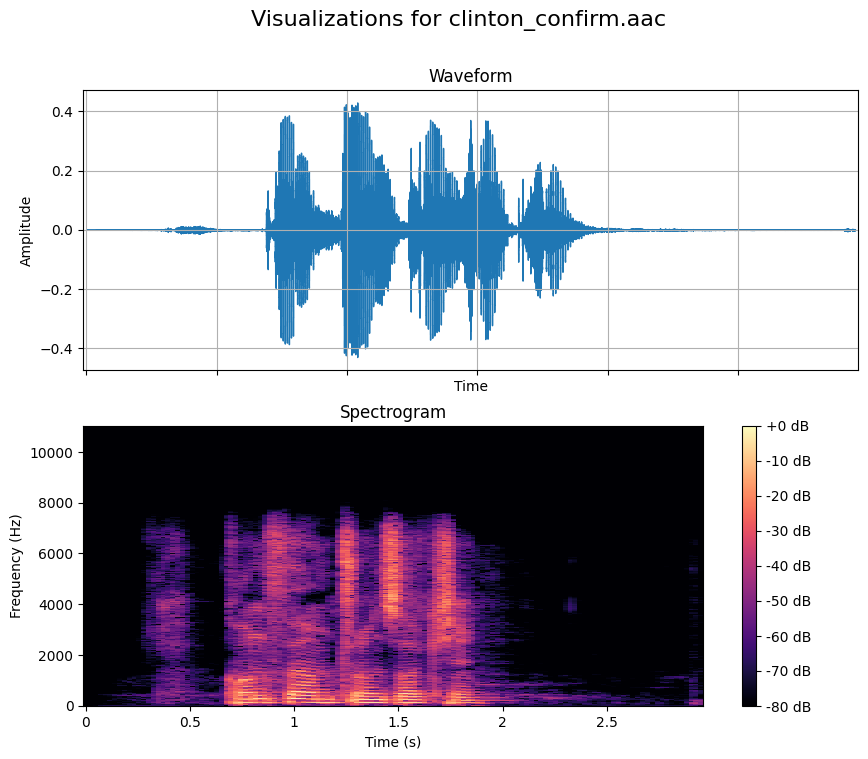

--- Processing: benitha_approve.aac ---


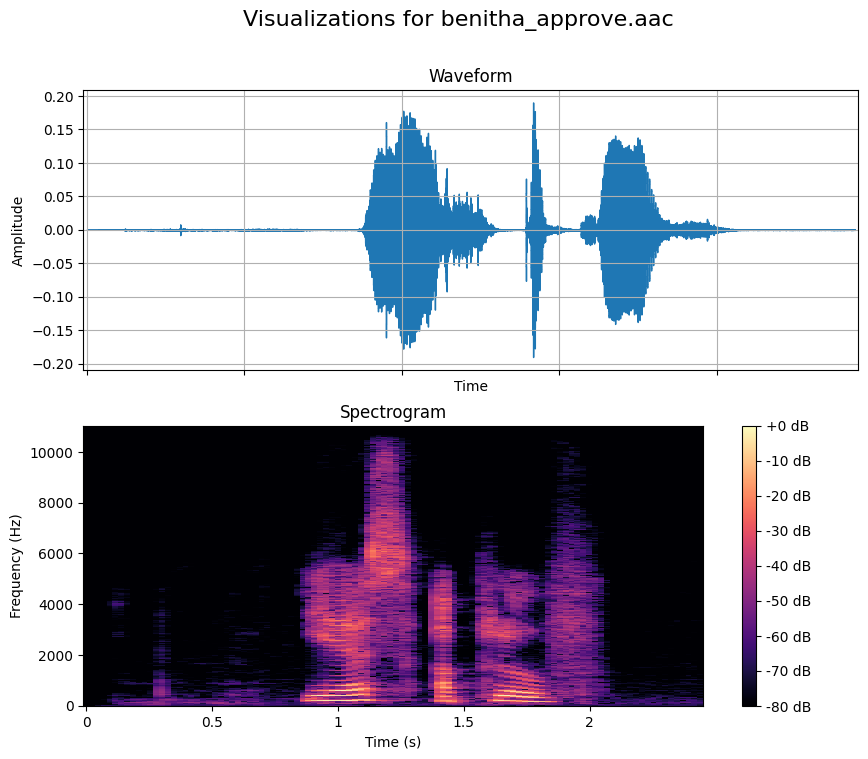

--- Processing: clinton_approve.aac ---


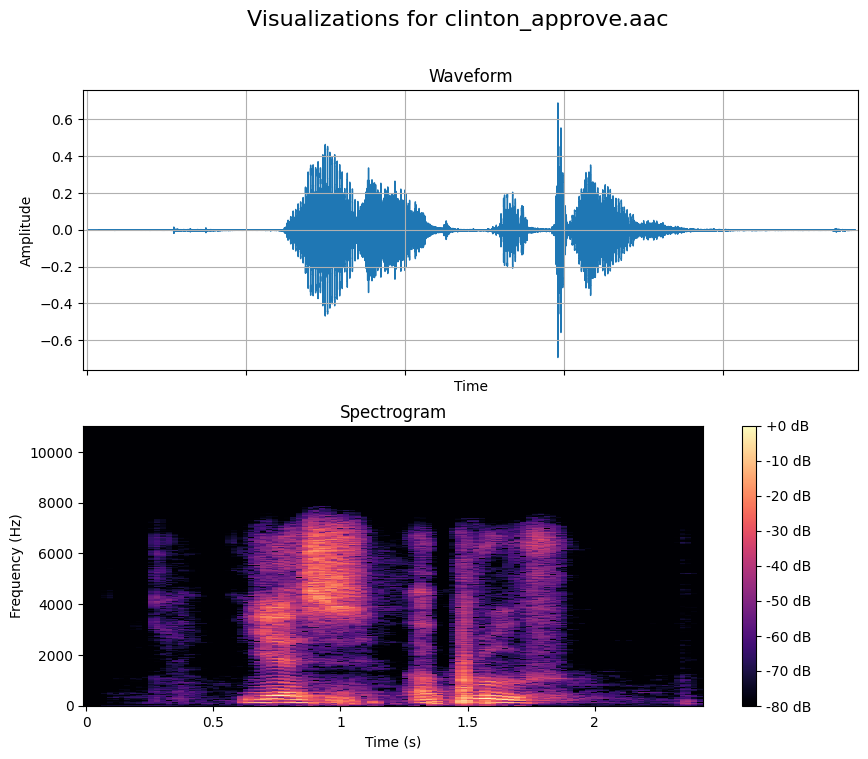

--- Processing: benitha_confirm.aac ---


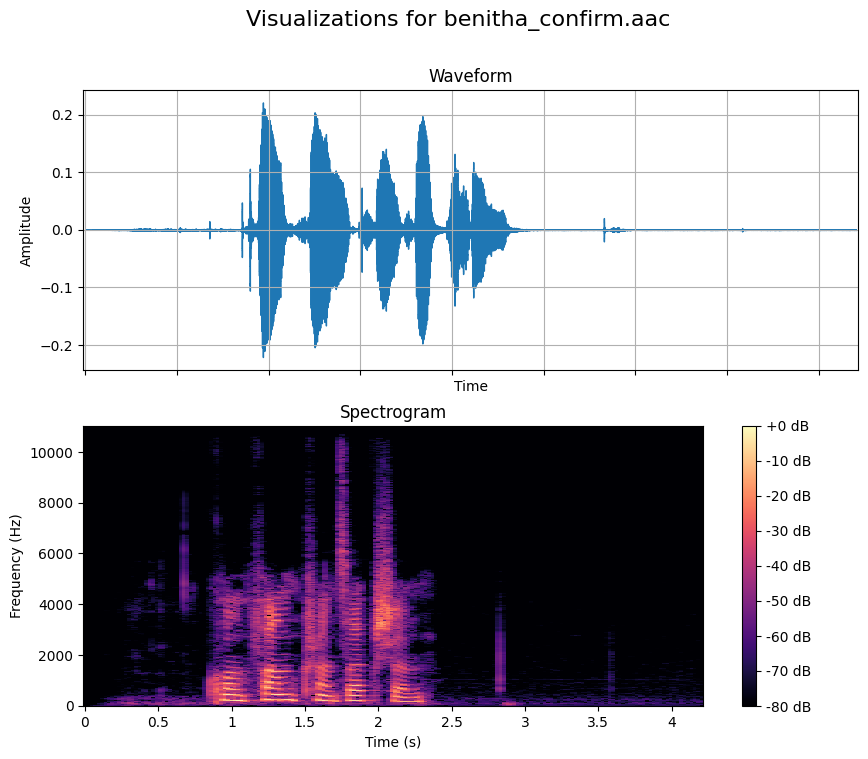

--- Processing: christian_confirm.ogg ---


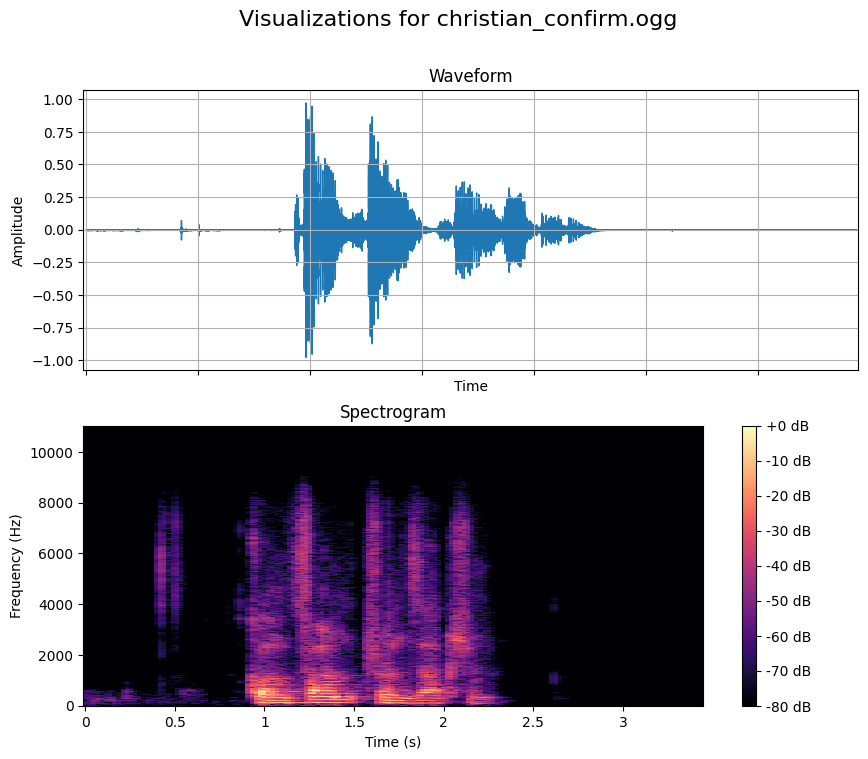

--- Processing: Jeremiah_approve.ogg ---


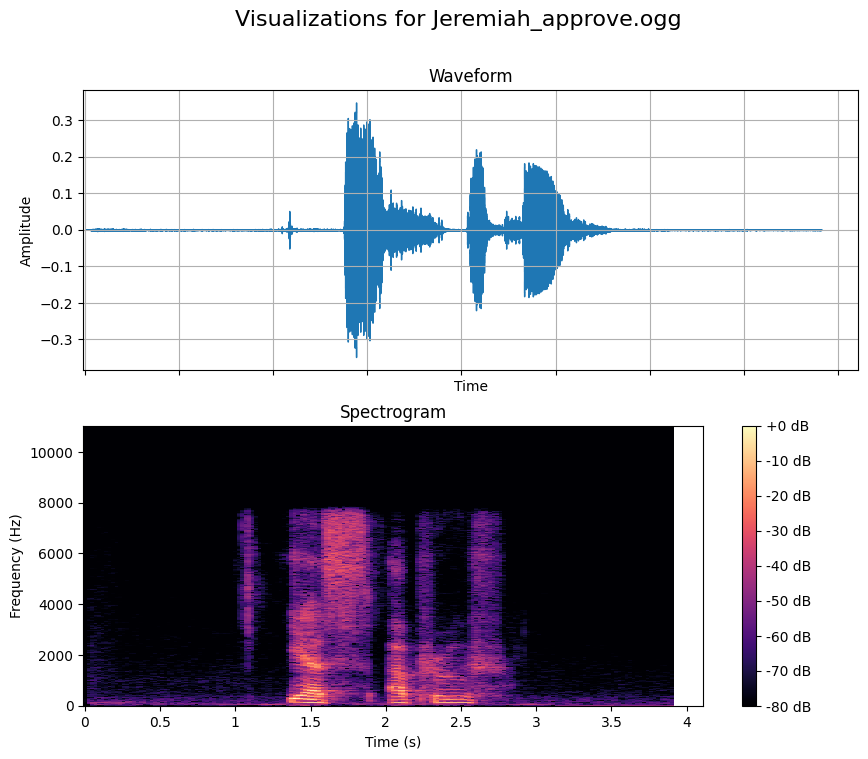

--- Processing: armand_confirm.ogg ---


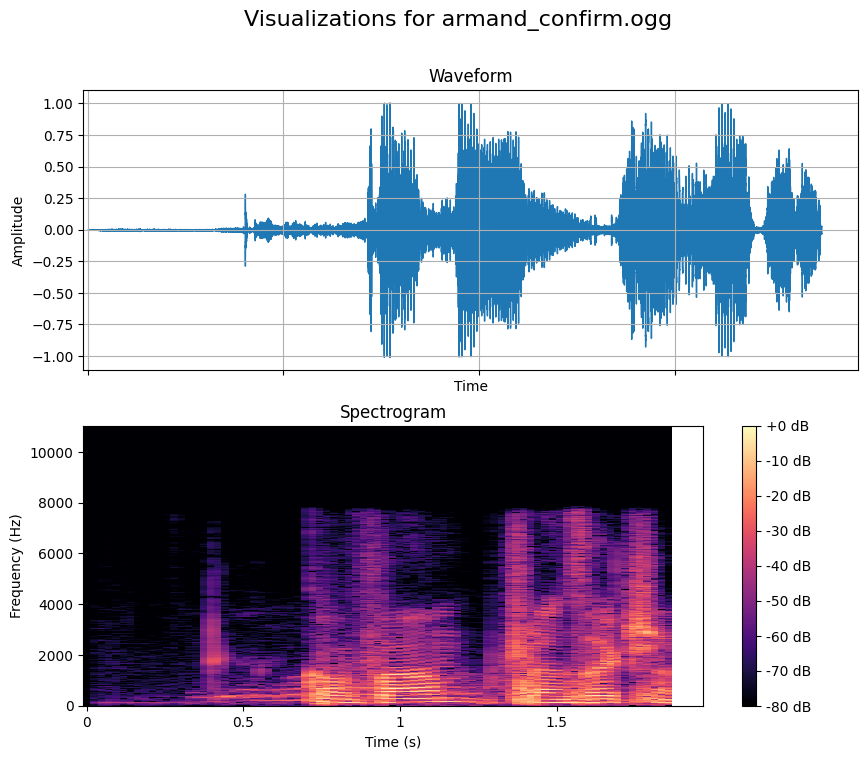

--- Processing: Jeremiah_confirm.ogg ---


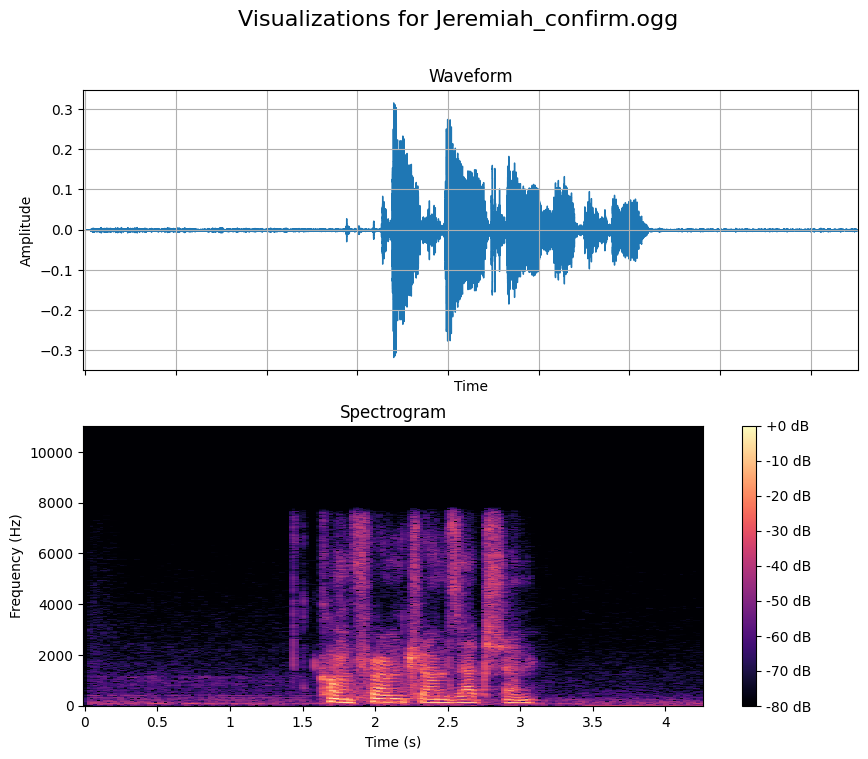

--- Processing: christian_approve.ogg ---


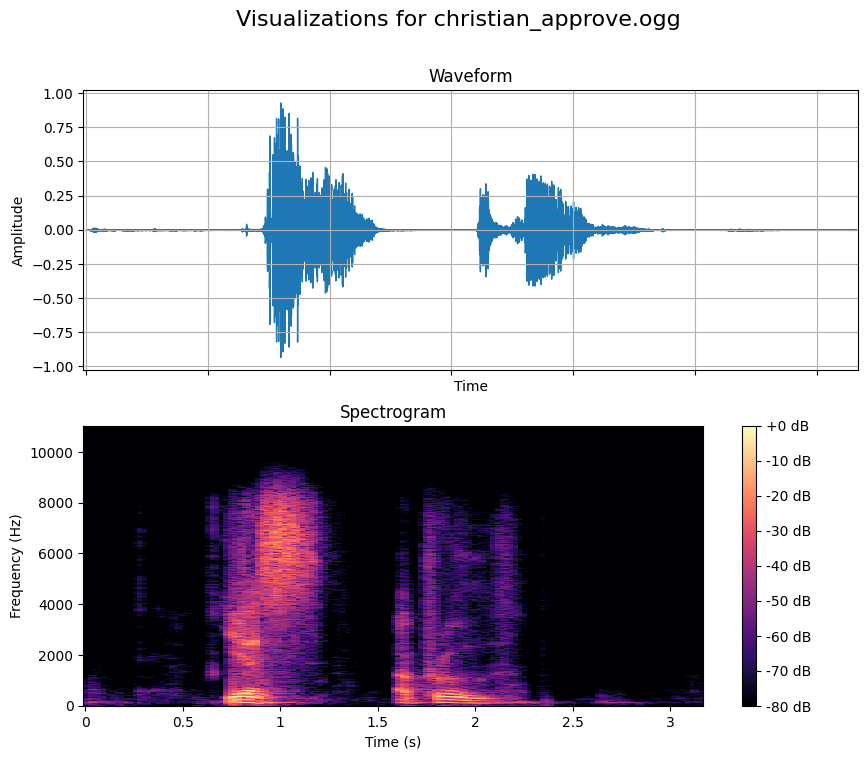

--- Processing: armand_approve.ogg ---


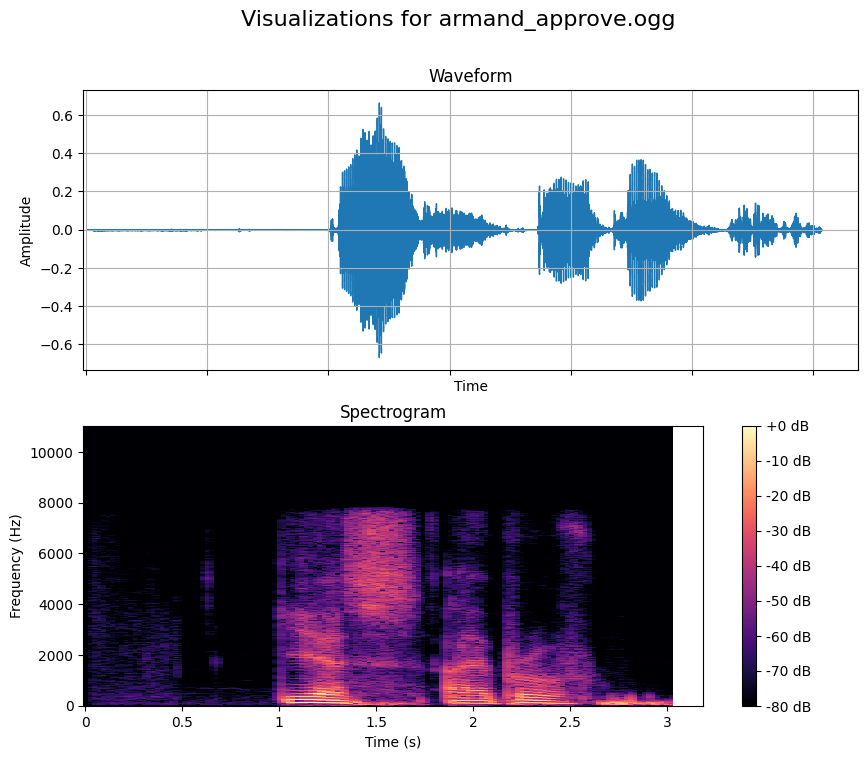

In [14]:
# Define the path to your audio files
audio_folder = '../data/audio/'
# Create a list of all audio files, regardless of format
audio_files = []
for extension in ['*.wav', '*.aac', '*.ogg']:
    audio_files.extend(glob.glob(os.path.join(audio_folder, extension)))

# Loop through each found audio file
for file_path in audio_files:
    try:
        # Load the audio file
        y, sr = librosa.load(file_path)
        file_name = os.path.basename(file_path)

        print(f"--- Processing: {file_name} ---")

        # Create a figure for the plots
        fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10, 8))
        fig.suptitle(f'Visualizations for {file_name}', fontsize=16)

        # 1. Plot the waveform
        librosa.display.waveshow(y, sr=sr, ax=ax[0])
        ax[0].set_title('Waveform')
        ax[0].set_ylabel('Amplitude')
        ax[0].grid(True)

        # 2. Plot the spectrogram
        D = librosa.stft(y)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax[1])
        ax[1].set_title('Spectrogram')
        ax[1].set_ylabel('Frequency (Hz)')
        ax[1].set_xlabel('Time (s)')
        fig.colorbar(img, ax=ax[1], format='%+2.0f dB')

        plt.show()

    except Exception as e:
        print(f"Could not process {file_path}. Error: {e}")

**Overall Interpretation**

After generating the visualizations for all audio files, we can make several key observations.
- **Data Quality:** The recordings are generally clean, with distinct periods of speech and silence visible in the waveforms. There's a noticeable variation in the recording amplitudes; for example, 
`christian_approve.ogg` and `armand_confirm.ogg` have much higher amplitudes (reaching +/- 1.0) compared to 
`benitha_approve.aac`  (around +/- 0.2). This indicates a need for volume normalization.

- **Consistency:** When comparing the same phrase across different speakers (e.g., "approve"), the waveforms consistently show two main bursts of sound corresponding to the two words "Yes, approve". While the general structure is consistent, the duration and specific shape of the waveforms differ for each person, which is expected.

- **Uniqueness:** The spectrograms clearly highlight the unique vocal characteristics of each speaker. Even when saying the same word, the patterns of the bright, high-energy frequency bands are distinct for each person. For instance, Christian's spectrograms show significant energy in higher frequencies , whereas Jeremiah's energy is more concentrated in the lower-to-mid frequencies. These unique "voiceprints" are exactly what the voice verification model will use to distinguish between individuals.

### Audio Augmentation & Feature Extraction
Now that we've inspected the audio, we'll process it for our model. This involves two steps:

1. **Augmentation:** Creating new training samples by slightly modifying the existing ones. This makes our model more robust.

2. **Feature Extraction:** Converting each audio clip into a single vector of numbers that represents its acoustic qualities.

#### Step 1: Define Augmentation Functions

We will define functions for the two augmentations we'll use: adding noise and shifting the pitch.

In [15]:
def add_noise(y, noise_factor=0.005):
    """Adds random noise to an audio signal."""
    noise = np.random.randn(len(y))
    augmented_data = y + noise_factor * noise
    # Cast back to same data type
    augmented_data = augmented_data.astype(type(y[0]))
    return augmented_data

def shift_pitch(y, sr, n_steps=2):
    """Shifts the pitch of an audio signal."""
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

#### Step 2: Define Feature Extraction Function

This function will take an audio signal and compute several types of features, then combine them into a single feature vector. We'll focus on MFCCs as they are powerful for voice recognition.

In [16]:
def extract_features(y, sr):
    """Extracts a feature vector from an audio signal."""
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs.T, axis=0)

    # Spectral Roll-off
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_mean = np.mean(rolloff)
    
    # Combine features into a single vector
    features = np.hstack((mfccs_mean, rolloff_mean))
    
    return features

#### Step 3: Process All Files and Save to CSV

Finally, we'll loop through all our audio files again. For each file, we'll extract features from the original audio and from two augmented versions. All results will be saved in a list and then converted to a DataFrame.

In [17]:
processed_data = []

for file_path in audio_files:
    try:
        # Load original audio
        y, sr = librosa.load(file_path)
        speaker = os.path.basename(file_path).split('_')[0]

        # 1. Features from Original Audio
        original_features = extract_features(y, sr)
        processed_data.append([speaker, *original_features, 'original'])

        # 2. Features from Noise-Augmented Audio
        y_noisy = add_noise(y)
        noisy_features = extract_features(y_noisy, sr)
        processed_data.append([speaker, *noisy_features, 'noise_augmented'])

        # 3. Features from Pitch-Shifted Audio
        y_pitched = shift_pitch(y, sr)
        pitched_features = extract_features(y_pitched, sr)
        processed_data.append([speaker, *pitched_features, 'pitch_augmented'])

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create a DataFrame
num_mfccs = 13
columns = ['speaker'] + [f'mfcc_{i+1}' for i in range(num_mfccs)] + ['spectral_rolloff', 'augmentation_type']
audio_features_df = pd.DataFrame(processed_data, columns=columns)

# Save the DataFrame to a CSV file
output_path = '../data/outputs/audio_features.csv'
audio_features_df.to_csv(output_path, index=False)

print(f"\nSuccessfully processed {len(audio_files)} files.")
print(f"DataFrame created with {len(audio_features_df)} total samples.")
print(f"Saved features to {output_path}")

# Display the first few rows of the new DataFrame
audio_features_df.head()

/var/folders/p7/mhf8qhy5037btnt6w33q98_r0000gn/T/ipykernel_8621/1780523607.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path)



Successfully processed 10 files.
DataFrame created with 30 total samples.
Saved features to ../data/outputs/audio_features.csv


,speaker,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,spectral_rolloff,augmentation_type
0,clinton,-435.134399,84.057556,5.001881,41.836685,-22.884861,11.222089,-1.638783,5.760222,-12.416693,-12.775623,-3.253028,-11.757052,0.688516,4010.474968,original
1,clinton,-261.224030,29.784676,12.873211,15.494253,-5.507101,2.125108,1.170265,-0.622046,-6.400784,-6.442492,-1.680954,-3.543177,-0.952627,7740.597725,noise_augmented
2,clinton,-458.286072,77.905609,11.470951,32.600555,-27.364946,16.773340,-7.411945,2.669729,-22.887775,-2.941316,-9.367432,-3.116752,-3.072914,4586.235809,pitch_augmented
3,benitha,-519.207458,70.423882,3.672397,37.972111,-14.393993,-3.612307,2.997492,-5.258861,-2.050553,-2.294870,3.053760,-5.394745,-9.373720,4294.452019,original
4,benitha,-291.247528,10.948599,4.532639,8.054706,-4.634600,-5.477114,-2.377530,-2.886595,-4.284879,-1.021075,0.639227,-2.489595,-1.676000,8507.240382,noise_augmented


## Part 2: Image Processing & Feature Extraction

In this section, we will process the raw facial images. The process involves:
- **Augmenting** each image to create additional training data. 
- **Extracting a numerical feature vector** (a color histogram) from each image. 
- **Saving these features** and their corresponding labels to a CSV file.

### Step 1: Define Feature Extraction & Augmentation Functions
We'll start by creating functions to handle our image operations. A color histogram is a great feature that represents the distribution of colors in an image.

In [21]:
def extract_histogram(image_path, bins=(8, 8, 8)):
    """Loads an image and computes a 3D color histogram."""
    image = cv2.imread(image_path)
    # Convert the image to the HSV color space and compute a histogram
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    # Normalize the histogram and flatten it
    cv2.normalize(hist, hist)
    return hist.flatten()

def augment_and_extract_features(image_path, bins=(8, 8, 8)):
    """Applies two augmentations and extracts features from each version."""
    image = cv2.imread(image_path)
    features = {}

    # 1. Rotated Augmentation
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, -10, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h))
    
    hsv_rotated = cv2.cvtColor(rotated, cv2.COLOR_BGR2HSV)
    hist_rotated = cv2.calcHist([hsv_rotated], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist_rotated, hist_rotated)
    features['rotated'] = hist_rotated.flatten()

    # 2. Flipped Augmentation
    flipped = cv2.flip(image, 1)
    
    hsv_flipped = cv2.cvtColor(flipped, cv2.COLOR_BGR2HSV)
    hist_flipped = cv2.calcHist([hsv_flipped], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist_flipped, hist_flipped)
    features['flipped'] = hist_flipped.flatten()
    
    return features

### Step 2: Process All Images and Save to CSV
Now we will loop through all the `.jpg` files in the `data/images/` folder, extract features from the original and two augmented versions, and save all the data to a DataFrame.

In [23]:
image_folder = '../data/images/'
image_files = glob.glob(os.path.join(image_folder, '*.jpg'))
processed_image_data = []

for file_path in image_files:
    try:
        person_name = os.path.basename(file_path).split('_')[0]

        # 1. Extract features from the original image
        original_hist = extract_histogram(file_path)
        processed_image_data.append([person_name, *original_hist, 'original'])

        # 2. Get features from augmented versions
        augmented_features = augment_and_extract_features(file_path)
        processed_image_data.append([person_name, *augmented_features['rotated'], 'rotated'])
        processed_image_data.append([person_name, *augmented_features['flipped'], 'flipped'])

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create the DataFrame
hist_size = 8 * 8 * 8 
columns = ['person'] + [f'hist_{i}' for i in range(hist_size)] + ['augmentation_type']
image_features_df = pd.DataFrame(processed_image_data, columns=columns)

# Save the DataFrame to a CSV file
output_path = '../data/outputs/image_features.csv'
image_features_df.to_csv(output_path, index=False)

print(f"\nSuccessfully processed {len(image_files)} images.")
print(f"DataFrame created with {len(image_features_df)} total samples.")
print(f"Saved features to {output_path}")

# Display the first few rows
image_features_df.head()


Successfully processed 15 images.
DataFrame created with 45 total samples.
Saved features to ../data/outputs/image_features.csv


,person,hist_0,hist_1,hist_2,hist_3,hist_4,hist_5,hist_6,hist_7,hist_8,...,hist_503,hist_504,hist_505,hist_506,hist_507,hist_508,hist_509,hist_510,hist_511,augmentation_type
0,Jeremiah,0.000003,0.000057,0.000021,0.000030,0.000042,0.000138,0.000325,0.092123,0.000087,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,original
1,Jeremiah,0.267169,0.000106,0.000086,0.000116,0.000126,0.000199,0.000417,0.084802,0.000526,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,rotated
2,Jeremiah,0.000003,0.000057,0.000021,0.000030,0.000042,0.000138,0.000325,0.092123,0.000087,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flipped
3,Jeremiah,0.000031,0.000031,0.000034,0.000051,0.000096,0.000167,0.000306,0.063572,0.000167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,original
4,Jeremiah,0.252178,0.000050,0.000091,0.000119,0.000172,0.000228,0.000378,0.063593,0.000522,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,rotated
